In [1]:
from sklearn.model_selection import train_test_split

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("../data/cleaned_gigs.csv")

In [4]:
df

,gig_title,rating_score,rating_counts,seller_level,category,basic_price,standard_price,premium_price,basic_delivery_days,standard_delivery_days,premium_delivery_days,basic_revision,basic_revision_unlimited,standard_revision,standard_revision_unlimited,premium_revision,premium_revision_unlimited,basic_features,standard_features,premium_features
0,I will design product advertisement poster and...,4.9,411,2,Poster Design,117.33,156.44,332.43,4,4,5,3.0,0,6.0,0,NaN,1,"1 Poster design + JPG, PNG, Print-Ready PDF Files",1 Poster design and 1 social media ad design +...,2 Poster designs & 6 social media ad designs +...
1,I will make an animated lottie json for web or...,5.0,576,3,Lottie & Web Animation,136.88,273.77,625.76,2,2,3,1.0,0,2.0,0,2.0,0,"Basic animation of one element - icon, button,...",Advanced animation of one element - logo -OR- ...,Complex animation of one detailed scene with c...
2,I will create high converting google ads ppc a...,4.9,27,2,Search Engine Marketing Management,567.09,1017.00,1350.00,4,7,10,1.0,0,1.0,0,1.0,0,Setup 1 Campaign + Keywords Research + High Q...,"Up to 3 Campaigns (Search, Display, Shopping),...","Up to 5 Campaigns (Search, Performanvce Max,Di..."
3,I will do editing and fact checking ai generat...,5.0,1,1,Fact Checking,19.55,39.11,58.66,1,1,1,0.0,0,0.0,0,0.0,0,i will write using chatgpt,i will write your content using chatgpt and edit,i will write your content using chatgpt and f...
4,I will create a pixel collectibles for nft col...,5.0,241,2,NFT Art,39.11,136.88,254.21,2,3,5,1.0,0,1.0,0,1.0,0,[CONTACT ME FIRST BEFORE ORDER]\r\nYou can get...,[CONTACT ME FIRST BEFORE ORDER]\r\nGet 10 TRAI...,[CONTACT ME FIRST BEFORE ORDER]\r\nGet 20 TRAI...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7164,I will create autopilot amazon affiliate website,5.0,584,2,WordPress,391.10,586.65,782.20,4,5,7,NaN,1,NaN,1,NaN,1,Complete Automatic Amazon Affiliate Website fo...,Complete Automatic Website with Mobile App + S...,Premium Quality Website with Unlimited Product...
7165,"I will do your box packaging design, packaging...",5.0,39,2,Packaging Design,117.33,293.32,351.99,2,3,5,9.0,0,NaN,1,NaN,1,â High-Quality Design\r\nâ Print-Ready File...,â Unique Branded Design \r\nâ High Pixel Pri...,â 2 Premium Design Concepts\r\nâ Branded Log...
7166,I will be your professional youtube channel ma...,4.9,60,2,YouTube Channel Management,136.88,293.32,782.20,7,14,30,NaN,0,NaN,0,NaN,0,"â Organic YouTube Promotion for 100+ Subs,â ...","â Organic YouTube Promotion â 500+ Subs, â ...","â 1000+ Subs, â 4000+ watch hours â 20 Vide..."
7167,I will perform IT governance cobit assessment ...,5.0,14,2,Data Governance & Protection,762.64,1545.00,2328.00,5,7,10,10.0,0,15.0,0,20.0,0,I&T Goveranance requirement,Processes + Assessment + Maturity Assessment i...,Processes + Assessment + Maturity Assessment i...


In [5]:
X = df[
    [
        "gig_title",
        "rating_score",
        "rating_counts",
        "seller_level",
        "category",
        "basic_delivery_days",
        "basic_revision",
        "basic_revision_unlimited",
        "basic_features"
    ]
]

In [6]:
y = df["basic_price"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [8]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5735, 9), (1434, 9), (5735,), (1434,))

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [10]:
tfidf_title = TfidfVectorizer()

X_train_title = tfidf_title.fit_transform(X_train["gig_title"])

In [11]:
X_train_title.shape

(5735, 4806)

In [12]:
X_test_title = tfidf_title.transform(X_test["gig_title"])

In [13]:
X_test_title.shape

(1434, 4806)

In [14]:
tfidf_basic_feature = TfidfVectorizer()

In [15]:
X_train_basic_feature = tfidf_basic_feature.fit_transform(X_train["basic_features"])

In [16]:
X_train_basic_feature.shape

(5735, 5813)

In [17]:
X_test_basic_feature = tfidf_basic_feature.transform(X_test["basic_features"])

In [18]:
X_test_basic_feature.shape

(1434, 5813)

In [19]:
from sklearn.preprocessing import OneHotEncoder

In [20]:
encoder = OneHotEncoder(sparse_output=False)

In [21]:
X_train_category = encoder.fit_transform(X_train[["category"]])

In [22]:
X_test_category = encoder.transform(X_test[["category"]])

In [23]:
numeric_features = [
    "rating_score",
    "rating_counts",
    "seller_level",
    "basic_delivery_days",
    "basic_revision",
    "basic_revision_unlimited"
]

In [24]:
from sklearn.impute import SimpleImputer

In [25]:
from sklearn.compose import ColumnTransformer

In [26]:
from sklearn.pipeline import Pipeline

In [27]:
numeric_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median"))])

In [28]:
category_pipeline = Pipeline([("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

In [29]:
column_transform = ColumnTransformer([
    ("title_tfidf", TfidfVectorizer(), "gig_title"),
    ("basic_feature_tfidf", TfidfVectorizer(), "basic_features"),
    ("numeric", numeric_pipeline, numeric_features),
    ("category_ohe", category_pipeline, ["category"])
])

In [30]:
X_train_transformed = column_transform.fit_transform(X_train)

In [31]:
X_train_transformed.shape

(5735, 11036)

In [32]:
X_test_transformed = column_transform.transform(X_test)

In [33]:
X_test_transformed.shape

(1434, 11036)

In [34]:
baseline_price = y_train.mean()

In [35]:
baseline_price

np.float64(280.2188526591107)

In [36]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [37]:
baseline_mae = mean_absolute_error(y_test, [baseline_price] * len(y_test))

In [38]:
baseline_mae

273.2705014026039

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

In [40]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


In [41]:
linear_regression = LinearRegression()
linear_regression.fit(X_train_transformed, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](11036,)","[-162.8 ,-432.13, 293.86,...,-250.28, -36.1 , 255.93]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,242.5
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11036


In [42]:
y_pred = linear_regression.predict(X_test_transformed)

In [43]:
mae = mean_absolute_error(y_test, y_pred)

In [44]:
mae

581.8184966925392

In [45]:
y_test,y_pred

(1892      78.22
 3757      39.38
 834      117.33
 7075      58.66
 257       78.22
          ...   
 3348      98.45
 6875      78.22
 2635     374.13
 3457      19.69
 7101    1760.00
 Name: basic_price, Length: 1434, dtype: float64,
 array([ 663.34340086, -361.94267456, -281.21656068, ...,  560.47812188,
         309.66315726, 2156.31272161], shape=(1434,)))

In [46]:
y_train.describe()

count     5735.000000
mean       280.218853
std       1080.352329
min         19.550000
25%         39.380000
50%         97.770000
75%        216.600000
max      35199.000000
Name: basic_price, dtype: float64

RIDGE

In [47]:
from sklearn.linear_model import Ridge


In [48]:
ridge_regression = Ridge()

ridge_regression.fit(X_train_transformed, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [49]:
y_pred_ridge = ridge_regression.predict(X_test_transformed)

In [50]:
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

In [51]:
mae_ridge

371.337363119939

Lasso

In [52]:
from sklearn.linear_model import Lasso


In [53]:
lasso_regression = Lasso()
lasso_regression.fit(X_train_transformed, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [54]:
y_pred_lasso = lasso_regression.predict(X_test_transformed)

In [55]:
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

In [56]:
mae_lasso

212.85968519959832

In [179]:
mse_basic = mean_squared_error(y_test, y_pred_lasso)
rmse_basic = np.sqrt(mse_basic)
r2_basic = r2_score(y_test, y_pred_lasso)

In [182]:
mse_basic

265039.8101428277

In [183]:
rmse_basic

np.float64(514.8201726261585)

In [184]:
r2_basic

0.22481882735091108

ElasticNet

In [57]:
from sklearn.linear_model import ElasticNet


In [58]:
elastic_net_regression = ElasticNet()
elastic_net_regression.fit(X_train_transformed, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",1.0
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet<sphx_glr_auto_examples_linear_model_plot_elastic_net_precomputed_gram_matrix_with_weighted_samples.py>`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [59]:
y_pred_elastic = elastic_net_regression.predict(X_test_transformed)

In [60]:
mae_elastic = mean_absolute_error(y_test, y_pred_elastic)

In [61]:
mae_elastic

228.3585359676909

Cross Val Score

In [62]:
from sklearn.model_selection import cross_val_score

In [63]:
lasso_pipeline = Pipeline([
    ("preprocessing", column_transform),
    ("model", Lasso())
])

In [64]:
cross_val_scores_lasso = cross_val_score(lasso_pipeline, X_train, y_train, cv=5, scoring="neg_mean_absolute_error")

In [65]:
cross_val_scores_lasso

array([-246.86357757, -313.54465118, -253.96823176, -219.14700515,
       -236.35072892])

In [66]:
mae_cv_lasso = -np.mean(cross_val_scores_lasso)

In [67]:
mae_cv_lasso

np.float64(253.97483891804958)

In [68]:
ridge_pipeline = Pipeline([
    ("preprocessing", column_transform),
    ("model", Ridge())
])

In [69]:
cross_val_scores_ridge = cross_val_score(ridge_pipeline, X_train, y_train, cv=5, scoring="neg_mean_absolute_error")

In [70]:
mae_cv_ridge = -np.mean(cross_val_scores_ridge)

In [71]:
mae_cv_ridge


np.float64(383.0148655996191)

In [72]:
elastic_net_pipeline = Pipeline([
    ("preprocessing", column_transform),
    ("model", ElasticNet())
])

In [73]:
cross_val_scores_elastic_net = cross_val_score(elastic_net_pipeline, X_train, y_train, cv=5, scoring="neg_mean_absolute_error")

In [74]:
mae_cv_elastic_net = -np.mean(cross_val_scores_elastic_net)

In [75]:
mae_cv_elastic_net

np.float64(263.3760147644358)

In [80]:
print({
    "Baseline MAE": baseline_mae,
    "Linear Test MAE": mae,
    "Ridge Test MAE": mae_ridge,
    "Ridge CV MAE": mae_cv_ridge,
    "Lasso Test MAE": mae_lasso,
    "Lasso CV MAE": mae_cv_lasso,
    "Elastic Net Test MAE": mae_elastic,
    "Elastic Net CV MAE": mae_cv_elastic_net
})

{'Baseline MAE': 273.2705014026039, 'Linear Test MAE': 581.8184966925392, 'Ridge Test MAE': 371.337363119939, 'Ridge CV MAE': np.float64(383.0148655996191), 'Lasso Test MAE': 212.85968519959832, 'Lasso CV MAE': np.float64(253.97483891804958), 'Elastic Net Test MAE': 228.3585359676909, 'Elastic Net CV MAE': np.float64(263.3760147644358)}


In [86]:
X_test.iloc[[11]]

,gig_title,rating_score,rating_counts,seller_level,category,basic_delivery_days,basic_revision,basic_revision_unlimited,basic_features
864,I will build blockchain website nft marketplac...,5.0,5,2,NFT Marketplace,10,2.0,0,I will develop front end using react and integ...


In [88]:
lasso_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['gig_title','rating_score','rating_counts',...,'basic_revision', 'basic_revision_unlimited','basic_features']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('title_tfidf', ...), ('basic_feature_tfidf', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto

In [89]:
prediction=lasso_pipeline.predict(X_test.iloc[[11]])

In [90]:
prediction

array([2697.03644314])

In [91]:
y_test.iloc[[11]]

864    1956.0
Name: basic_price, dtype: float64

In [92]:
sample_20=X_test.sample(20,random_state=42)

In [93]:
prediction=lasso_pipeline.predict(sample_20)

In [102]:
prediction

array([1080.46247453,  203.51213967,   16.17913397,  118.67926334,
        349.26401425,   66.81251747,  170.37344422,  268.27251515,
         43.69831774,  240.13909795,  375.71303169,  217.01175195,
        111.6707006 ,  217.6086019 ,   86.71502142,  178.55014395,
         15.66933618,  203.34471302,  222.29314465,  152.22389324])

In [98]:
actual=y_test.loc[sample_20.index]

In [99]:
actual

2542    511.96
4686    118.15
1086     97.77
2179     59.07
3050    315.06
90      195.55
1922    391.10
4857     39.38
2516     98.45
6065    313.18
1830     58.66
5199    137.84
731     117.33
4487     98.45
4817     78.76
1422     97.77
2029     39.11
1161    234.66
148      58.66
4389     39.38
Name: basic_price, dtype: float64

In [103]:
mae_sample_20=mean_absolute_error(y_test.loc[sample_20.index],lasso_pipeline.predict(sample_20))

In [104]:
mae_sample_20

123.82143672832763

In [106]:
y_pred = lasso_pipeline.predict(X_test)

In [107]:
y_pred

array([  48.06944329,  411.60520956,  120.56048572, ...,  274.28425782,
        112.05881768, 2563.14730865], shape=(1434,))

In [113]:
import matplotlib.pyplot as plt
%matplotlib inline

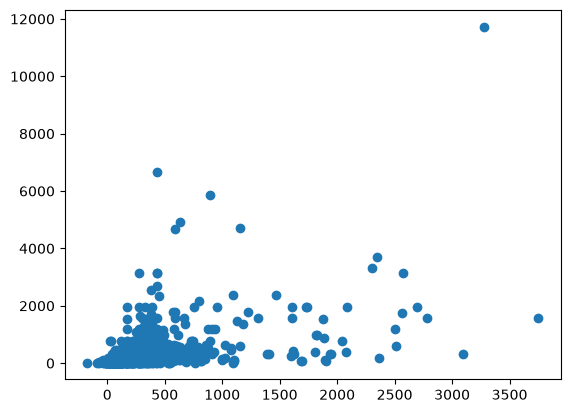

In [114]:
plt.scatter(y_pred,y_test)

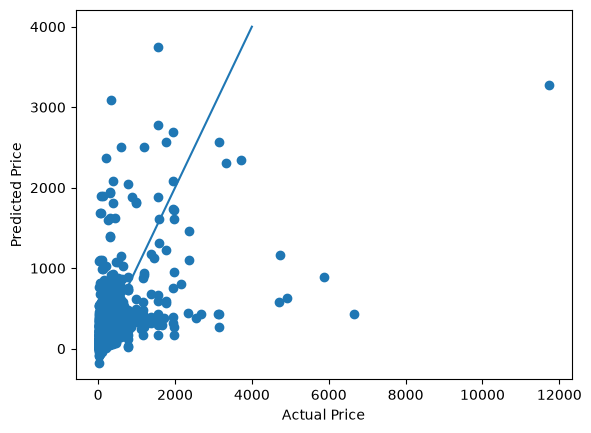

In [115]:
plt.scatter(y_test, y_pred)

plt.plot([0, 4000], [0, 4000])

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

In [116]:
X_standard = df[
    [
        "gig_title",
        "rating_score",
        "rating_counts",
        "seller_level",
        "category",
        "standard_delivery_days",
        "standard_revision",
        "standard_revision_unlimited",
        "standard_features"
    ]
]


In [117]:
y_standard = df["standard_price"]

In [118]:
X_train_standard, X_test_standard, y_train_standard, y_test_standard = train_test_split(X_standard, y_standard, test_size=0.2, random_state=0)

In [130]:
numeric_features_standard = [ 
    "rating_score",
    "rating_counts",
    "seller_level",
    "standard_delivery_days",
    "standard_revision",
    "standard_revision_unlimited"
]

In [131]:
numeric_pipeline_standard = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("Scaler", StandardScaler())
])

In [132]:
category_pipeline_standard = Pipeline([
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

In [133]:
column_transform_standard = ColumnTransformer([
    ("title_tfidf", TfidfVectorizer(), "gig_title"),
    ("standard_features_tfidf", TfidfVectorizer(), "standard_features"),
    ("categry_ohe",category_pipeline_standard, ["category"]),
    ("numeric", numeric_pipeline_standard,numeric_features_standard)
])

In [134]:
X_train_transformed_standard = column_transform_standard.fit_transform(X_train_standard)

In [135]:
X_test_transformed_standard = column_transform_standard.transform(X_test_standard)

In [137]:
lasso_standard = Lasso()

In [138]:
lasso_standard.fit(X_train_transformed_standard,y_train_standard)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [139]:
y_pred_standard = lasso_standard.predict(X_test_transformed_standard)

In [140]:
mae_lasso_standard = mean_absolute_error(y_test_standard,y_pred_standard)

In [141]:
mae_lasso_standard

514.4748131737015

In [150]:
X_premium = df[
    [
        "gig_title",
        "rating_score",
        "rating_counts",
        "seller_level",
        "category",
        "premium_delivery_days",
        "premium_revision",
        "premium_revision_unlimited",
        "premium_features"
    ]
]


In [151]:
y_premium = df["premium_price"]

In [152]:
X_train_premium, X_test_premium, y_train_premium, y_test_premium = train_test_split(X_premium, y_premium, test_size=0.2, random_state=0)

In [153]:
numeric_features_premium = [ 
    "rating_score",
    "rating_counts",
    "seller_level",
    "premium_delivery_days",
    "premium_revision",
    "premium_revision_unlimited"
]

In [154]:
numeric_pipeline_premium = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("Scaler", StandardScaler())
])

In [155]:
category_pipeline_premium = Pipeline([
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

In [156]:
column_transform_premium = ColumnTransformer([
    ("title_tfidf", TfidfVectorizer(), "gig_title"),
    ("premium_features_tfidf", TfidfVectorizer(), "premium_features"),
    ("categry_ohe",category_pipeline_premium, ["category"]),
    ("numeric", numeric_pipeline_premium,numeric_features_premium)
])

In [161]:
X_train_transformed_premium = column_transform_premium.fit_transform(X_train_premium)

In [162]:
X_test_transformed_premium = column_transform_premium.transform(X_test_premium)

In [163]:
lasso_premium = Lasso()

In [164]:
lasso_premium.fit(X_train_transformed_premium,y_train_premium)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [165]:
y_pred_premium = lasso_premium.predict(X_test_transformed_premium)

In [166]:
mae_lasso_premium = mean_absolute_error(y_test_premium,y_pred_premium)

In [167]:
mae_lasso_premium

1045.7230313813

In [168]:
ridge_standard = Ridge()
ridge_standard.fit(X_train_transformed_standard, y_train_standard)
y_pred_ridge_standard = ridge_standard.predict(X_test_transformed_standard)
mae_ridge_standard = mean_absolute_error(y_test_standard, y_pred_ridge_standard)

In [169]:
mae_ridge_standard

709.9068061502021

In [170]:
elastic_net_standard = ElasticNet()
elastic_net_standard.fit(X_train_transformed_standard, y_train_standard)
y_pred_elastic_standard = elastic_net_standard.predict(X_test_transformed_standard)
mae_elastic_standard = mean_absolute_error(y_test_standard, y_pred_elastic_standard)

In [171]:
mae_elastic_standard

555.8853823058992

In [172]:
ridge_premium = Ridge()
ridge_premium.fit(X_train_transformed_premium, y_train_premium)
y_pred_ridge_premium = ridge_premium.predict(X_test_transformed_premium)
mae_ridge_premium = mean_absolute_error(y_test_premium, y_pred_ridge_premium)

In [173]:
mae_ridge_premium

1396.1937420414458

In [174]:
elastic_net_premium = ElasticNet()
elastic_net_premium.fit(X_train_transformed_premium, y_train_premium)
y_pred_elastic_premium = elastic_net_premium.predict(X_test_transformed_premium)
mae_elastic_premium = mean_absolute_error(y_test_premium, y_pred_elastic_premium)

In [175]:
mae_elastic_premium

1081.7444871193604

In [177]:
import joblib

In [178]:
joblib.dump(lasso_regression, "../models/lasso_basic.pkl")
joblib.dump(column_transform, "../models/preprocessor_basic.pkl")

joblib.dump(lasso_standard, "../models/lasso_standard.pkl")
joblib.dump(column_transform_standard, "../models/preprocessor_standard.pkl")

joblib.dump(lasso_premium, "../models/lasso_premium.pkl")
joblib.dump(column_transform_premium, "../models/preprocessor_premium.pkl")

['../models/preprocessor_premium.pkl']